In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import json
import os

# Updated path to look inside the 'train' folder
dataset_path = '/content/drive/MyDrive/AADHAAR-CARD-DETAILS.coco'
train_path = os.path.join(dataset_path, 'train')

if os.path.isdir(train_path):
    print(f"Checking for annotations in: {train_path}")
    json_files = [f for f in os.listdir(train_path) if f.endswith('.json')]

    if json_files:
        annotation_path = os.path.join(train_path, json_files[0])
        print(f"Found annotation file: {annotation_path}")

        with open(annotation_path, 'r') as f:
            data = json.load(f)

        print(f"\nKeys in COCO file: {list(data.keys())}")
        if 'categories' in data:
            print(f"Categories: {[cat['name'] for cat in data['categories']]}")
        if 'images' in data:
            print(f"Number of images: {len(data['images'])}")
        if 'annotations' in data:
            print(f"Number of annotations: {len(data['annotations'])}")
    else:
        print("No .json file found in the 'train' folder. Here are the contents:")
        print(os.listdir(train_path))
else:
    print(f"'train' folder not found at {train_path}. Contents of root:")
    print(os.listdir(dataset_path))

Checking for annotations in: /content/drive/MyDrive/AADHAAR-CARD-DETAILS.coco/train
Found annotation file: /content/drive/MyDrive/AADHAAR-CARD-DETAILS.coco/train/_annotations.coco.json

Keys in COCO file: ['info', 'licenses', 'categories', 'images', 'annotations']
Categories: ['AADHAAR-CARD-DETAILS', '0', '1', '2', '3', '4']
Number of images: 2645
Number of annotations: 10310


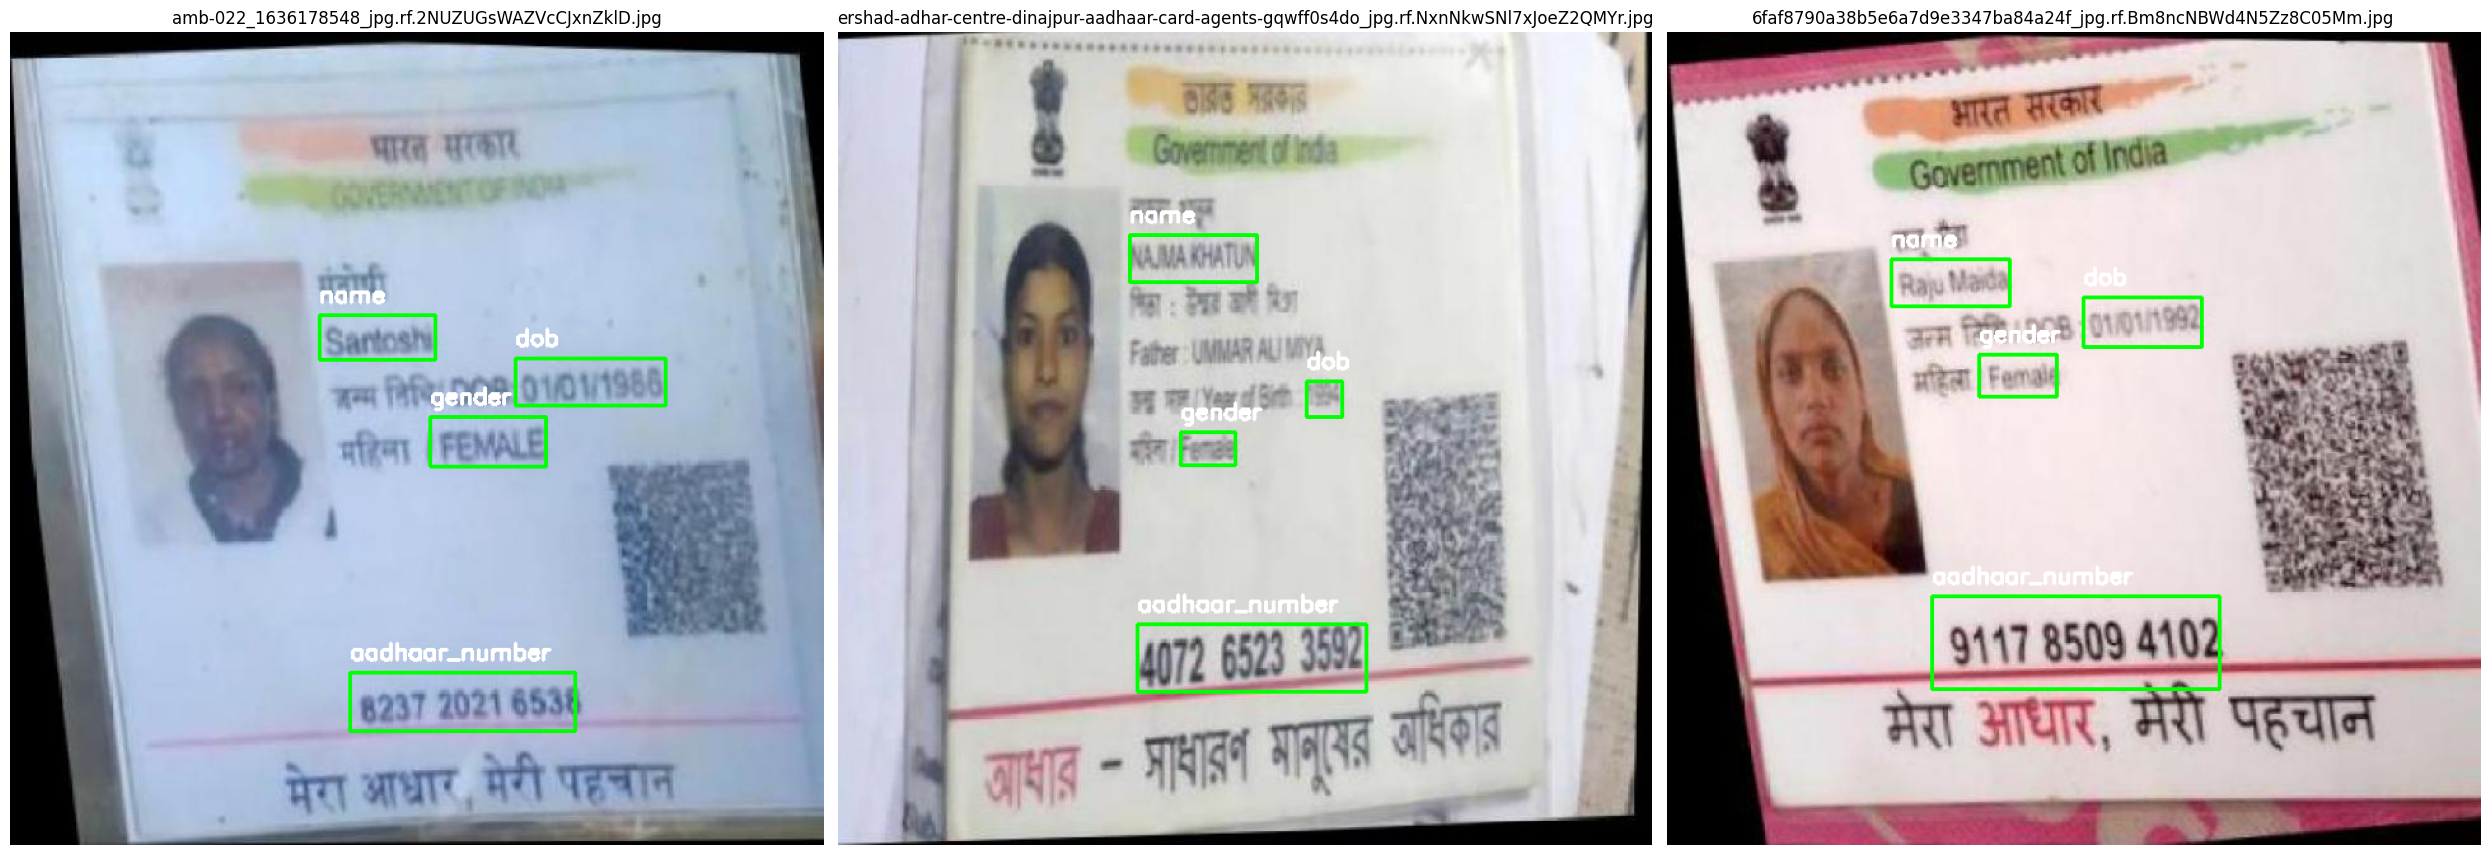

In [4]:
import cv2
import matplotlib.pyplot as plt
import random
import os

# Mapping provided by user context
category_map = {
    1: 'aadhaar_number',
    2: 'dob',
    3: 'gender',
    4: 'name',
    5: 'address'
}

# Visualize a few random images from the dataset
num_samples = 3
sample_images = random.sample(data['images'], num_samples)

fig, axs = plt.subplots(1, num_samples, figsize=(25, 12))

for i, img_info in enumerate(sample_images):
    img_path = os.path.join(train_path, img_info['file_name'])
    image = cv2.imread(img_path)
    if image is None:
        print(f"Could not load image: {img_path}")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw annotations
    img_id = img_info['id']
    ann_list = [ann for ann in data['annotations'] if ann['image_id'] == img_id]

    for ann in ann_list:
        cat_id = ann['category_id']
        label = category_map.get(cat_id, f"Unknown ({cat_id})")

        bbox = ann['bbox'] # [x, y, width, height]
        x, y, w, h = [int(v) for v in bbox]

        # Draw box
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Draw label background and text
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    axs[i].imshow(image)
    axs[i].set_title(img_info['file_name'])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
import os
import json
import yaml
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==========================================
# Configuration
# ==========================================
DATASET_ROOT = '/content/drive/MyDrive/AADHAAR-CARD-DETAILS.coco'
IMAGE_SRC = os.path.join(DATASET_ROOT, 'train')
ANNOTATION_FILE = os.path.join(IMAGE_SRC, '_annotations.coco.json')
OUTPUT_DIR = '/content/aadhaar_yolo'

# Map original meaningless numeric classes to YOLO 0-indexed semantic classes
YAML_CLASSES = ['aadhaar_number', 'dob', 'gender', 'name', 'address']
CLASS_MAP = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}

# ==========================================
# Initialization
# ==========================================
def setup_directories(base_dir):
    """Creates the standard YOLOv8 directory structure."""
    dirs = [
        'images/train', 'images/val',
        'labels/train', 'labels/val'
    ]
    for d in dirs:
        os.makedirs(os.path.join(base_dir, d), exist_ok=True)

setup_directories(OUTPUT_DIR)

# Load COCO annotations
print(f"Loading annotations from {ANNOTATION_FILE}...")
with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

# Group annotations by image_id for faster lookup
img_to_anns = defaultdict(list)
for ann in coco_data['annotations']:
    img_to_anns[ann['image_id']].append(ann)

# ==========================================
# Deterministic Train/Val Split
# ==========================================
# Split the 2645 images into 2249 train and 396 val (using random_state=42 for reproducibility)
train_imgs, val_imgs = train_test_split(
    coco_data['images'],
    test_size=396,
    random_state=42
)

# ==========================================
# Conversion Logic
# ==========================================
def convert_to_yolo(images, split_name):
    """Copies images and converts COCO labels to YOLO txt files with a progress bar."""
    for img in tqdm(images, desc=f"Processing {split_name} Split"):
        img_id = img['id']
        img_name = img['file_name']
        w_img, h_img = img['width'], img['height']

        # 1. Copy the image to the appropriate YOLO split folder
        src_image_path = os.path.join(IMAGE_SRC, img_name)
        dst_image_path = os.path.join(OUTPUT_DIR, f'images/{split_name}', img_name)

        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
        else:
            tqdm.write(f"Warning: Image {img_name} not found. Skipping.")
            continue

        # 2. Write the YOLO label txt file
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(OUTPUT_DIR, f'labels/{split_name}', label_name)

        with open(label_path, 'w') as lf:
            for ann in img_to_anns.get(img_id, []):
                cat_id = ann['category_id']

                # Skip classes outside our target mapping
                if cat_id not in CLASS_MAP:
                    continue

                yolo_class_id = CLASS_MAP[cat_id]
                x, y, w, h = ann['bbox']

                # Convert COCO [x_min, y_min, width, height] -> YOLO normalized [x_center, y_center, width, height]
                cx = (x + w / 2) / w_img
                cy = (y + h / 2) / h_img
                norm_w = w / w_img
                norm_h = h / h_img

                # Ensure coordinates are tightly bounded within [0, 1] to prevent YOLO warnings
                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                norm_w = max(0.0, min(1.0, norm_w))
                norm_h = max(0.0, min(1.0, norm_h))

                lf.write(f"{yolo_class_id} {cx:.6f} {cy:.6f} {norm_w:.6f} {norm_h:.6f}\n")

# Run conversions
convert_to_yolo(train_imgs, 'train')
convert_to_yolo(val_imgs, 'val')

# ==========================================
# Generate data.yaml
# ==========================================
data_yaml = {
    'path': OUTPUT_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: name for i, name in enumerate(YAML_CLASSES)}
}

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"\n✅ Conversion complete! YOLOv8 dataset ready at: {OUTPUT_DIR}")
print(f"✅ data.yaml generated at: {yaml_path}")

Loading annotations from /content/drive/MyDrive/AADHAAR-CARD-DETAILS.coco/train/_annotations.coco.json...


Processing val Split: 100%|██████████| 396/396 [00:01<00:00, 279.47it/s]


✅ Conversion complete! YOLOv8 dataset ready at: /content/aadhaar_yolo
✅ data.yaml generated at: /content/aadhaar_yolo/data.yaml


In [6]:
# Install the Ultralytics package (if not already installed in this session)
!pip install ultralytics -q

from ultralytics import YOLO

# Load the pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model on your custom dataset
# We use imgsz=640 as specified in your dataset description
results = model.train(
    data='/content/aadhaar_yolo/data.yaml',
    epochs=50,             # Adjust based on how quickly it converges
    imgsz=640,             # Your target image size
    batch=16,              # Safe batch size for standard Colab T4 GPU
    project='aadhaar_layout',
    name='train_v1',
    device=0               # Forces it to use the GPU
)

print("\n✅ Training initiated! Check the 'aadhaar_layout/train_v1/weights' folder for best.pt when done.")

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/aadhaar_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [7]:
import shutil
shutil.copy('/content/runs/detect/aadhaar_layout/train_v1-2/weights/best.pt', '/content/drive/MyDrive/best_layout_detector.pt')

'/content/drive/MyDrive/best_layout_detector.pt'

Running inference on: 3564191365d6dd7bff705c3252860029_jpg.rf.1Jbq59lyuUcFvTbTxZQ0.jpg

image 1/1 /content/aadhaar_yolo/images/val/3564191365d6dd7bff705c3252860029_jpg.rf.1Jbq59lyuUcFvTbTxZQ0.jpg: 640x640 1 aadhaar_number, 1 dob, 1 gender, 1 name, 36.4ms
Speed: 14.8ms preprocess, 36.4ms inference, 9.0ms postprocess per image at shape (1, 3, 640, 640)


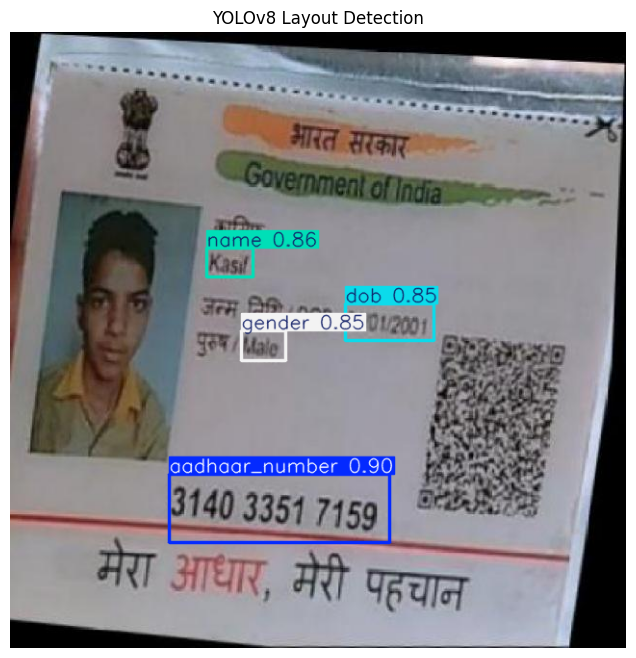


--- Cropped Fields Ready for OCR ---


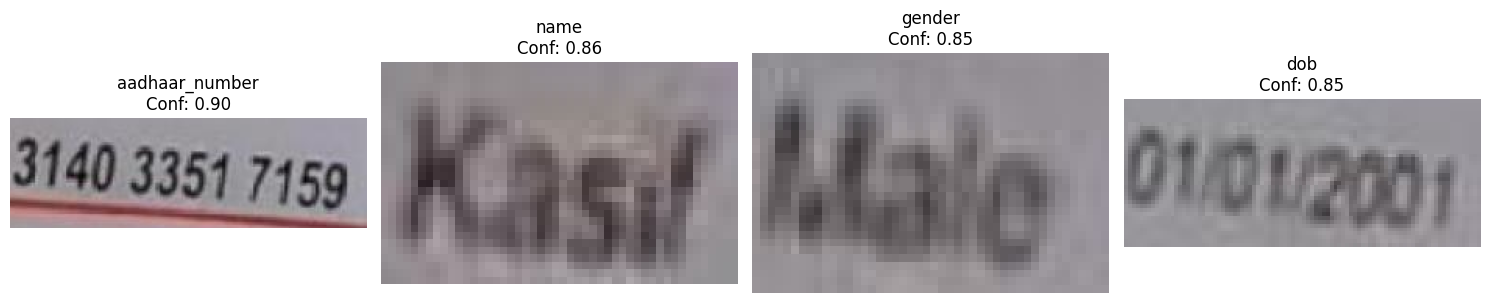

In [8]:
import cv2
import random
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your newly trained layout detector
model = YOLO('/content/drive/MyDrive/best_layout_detector.pt')

# 2. Pick a random image from the validation set
val_images_dir = '/content/aadhaar_yolo/images/val'
test_image_name = random.choice(os.listdir(val_images_dir))
test_image_path = os.path.join(val_images_dir, test_image_name)

print(f"Running inference on: {test_image_name}")

# 3. Run inference (we'll use a strict 60% confidence threshold)
results = model.predict(source=test_image_path, conf=0.6)

# 4. Display the overall layout detections
res_plotted = results[0].plot(line_width=2, font_size=1)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8 Layout Detection")
plt.axis('off')
plt.show()

# 5. Extract and display the individual crops for the OCR pipeline
print("\n--- Cropped Fields Ready for OCR ---")
original_image = cv2.imread(test_image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

class_names = model.names
boxes = results[0].boxes

if len(boxes) > 0:
    # Create a subplot for each crop
    fig, axs = plt.subplots(1, len(boxes), figsize=(15, 3))
    if len(boxes) == 1:
        axs = [axs] # Fix for single detection bug

    for i, box in enumerate(boxes):
        # Extract coordinates, class, and confidence
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0].item())
        conf = box.conf[0].item()
        label = class_names[cls_id]

        # Slice the numpy array to get the crop
        crop = original_image[y1:y2, x1:x2]

        # Plot it
        axs[i].imshow(crop)
        axs[i].set_title(f"{label}\nConf: {conf:.2f}")
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No fields detected over the confidence threshold!")

In [9]:
class BeliefMass:
    """
    Represents the Basic Probability Assignment (BPA) for a single source of evidence.
    Keys: 'G' (Genuine), 'T' (Tampered), 'U' (Uncertainty / {G, T})
    """
    def __init__(self, genuine=0.0, tampered=0.0, uncertainty=1.0):
        total = genuine + tampered + uncertainty
        # Normalize to ensure masses sum to exactly 1.0
        self.mass = {
            'G': genuine / total,
            'T': tampered / total,
            'U': uncertainty / total
        }

    def combine(self, other):
        """
        Combines this mass with another using Dempster's Rule of Combination.
        """
        m1 = self.mass
        m2 = other.mass

        # Calculate intersection areas
        # G intersects with G and U -> G
        G_intersect = (m1['G'] * m2['G']) + (m1['G'] * m2['U']) + (m1['U'] * m2['G'])

        # T intersects with T and U -> T
        T_intersect = (m1['T'] * m2['T']) + (m1['T'] * m2['U']) + (m1['U'] * m2['T'])

        # U intersects with U -> U
        U_intersect = m1['U'] * m2['U']

        # Calculate conflict (K) - where G and T intersect, which is an impossible state
        conflict = (m1['G'] * m2['T']) + (m1['T'] * m2['G'])

        # If conflict is 1.0, sources are completely contradictory (divide by zero protection)
        if conflict >= 1.0:
            raise ValueError("100% Conflict between evidence sources. Cannot combine.")

        # Normalize by (1 - conflict)
        normalization_factor = 1.0 - conflict

        return BeliefMass(
            genuine = G_intersect / normalization_factor,
            tampered = T_intersect / normalization_factor,
            uncertainty = U_intersect / normalization_factor
        )

    def __repr__(self):
        return f"Genuine: {self.mass['G']:.4f} | Tampered: {self.mass['T']:.4f} | Uncertainty: {self.mass['U']:.4f}"

# ==========================================
# Simulating Your Pipeline's Fusion
# ==========================================

print("--- Dempster-Shafer Evidence Fusion ---")

# 1. LAYOUT EVIDENCE (from YOLOv8)
# E.g., All 4 fields found, but slightly misaligned.
# Strong belief it's genuine, low belief it's tampered, some uncertainty.
evidence_layout = BeliefMass(genuine=0.70, tampered=0.10, uncertainty=0.20)
print(f"1. Layout Branch:   {evidence_layout}")

# 2. SEMANTIC EVIDENCE (from OCR + QR + Verhoeff)
# E.g., Verhoeff check passes, but DOB OCR doesn't perfectly match QR string.
# Moderate suspicion of tampering.
evidence_semantic = BeliefMass(genuine=0.40, tampered=0.50, uncertainty=0.10)
print(f"2. Semantic Branch: {evidence_semantic}")

# 3. VISUAL FORGERY EVIDENCE (from .pth model)
# E.g., ELA and noise analysis detect heavy pixel manipulation.
# Very strong belief it is tampered.
evidence_visual = BeliefMass(genuine=0.05, tampered=0.85, uncertainty=0.10)
print(f"3. Visual Branch:   {evidence_visual}")

print("-" * 50)

# ==========================================
# Execute the Fusion
# ==========================================
# Combine Layout + Semantic
combined_step_1 = evidence_layout.combine(evidence_semantic)
print(f"Fusion (1 + 2):     {combined_step_1}")

# Combine Result + Visual Forgery
final_belief = combined_step_1.combine(evidence_visual)
print(f"Final Fusion:       {final_belief}")

print("=" * 50)
# Final Verdict Logic
if final_belief.mass['T'] > final_belief.mass['G']:
    print(f"🚨 VERDICT: TAMPERED (Confidence: {final_belief.mass['T']*100:.2f}%)")
else:
    print(f"✅ VERDICT: GENUINE (Confidence: {final_belief.mass['G']*100:.2f}%)")

--- Dempster-Shafer Evidence Fusion ---
1. Layout Branch:   Genuine: 0.7000 | Tampered: 0.1000 | Uncertainty: 0.2000
2. Semantic Branch: Genuine: 0.4000 | Tampered: 0.5000 | Uncertainty: 0.1000
3. Visual Branch:   Genuine: 0.0500 | Tampered: 0.8500 | Uncertainty: 0.1000
--------------------------------------------------
Fusion (1 + 2):     Genuine: 0.7049 | Tampered: 0.2623 | Uncertainty: 0.0328
Final Fusion:       Genuine: 0.2770 | Tampered: 0.7146 | Uncertainty: 0.0085
🚨 VERDICT: TAMPERED (Confidence: 71.46%)
